# Feature Engineering & Data Quality
### Titanic: Machine Learning from Disaster

**Objective:** Improve the predictive signal for passenger survival through hypothesis-driven feature engineering, and audit the dataset for quality issues that could make a model unreliable or biased.

**Target:** `Survived` (1 = survived, 0 = did not survive), a binary classification task.

**Dataset:** Kaggle `train.csv`, 891 passengers. Kaggle's `test.csv` is not used because it has no labels; instead, a held-out test set is created from `train.csv`.

**Notebook structure**
1. Setup & data loading
2. Data-quality audit
3. Leakage & class imbalance checks
4. Train/test split & baseline pipeline
5. Feature engineering (with hypotheses)
6. Engineered model
7. Before/after comparison & hypothesis evaluation
8. Conclusion

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, f1_score, classification_report

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

df = pd.read_csv("data/train.csv")
print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


### Column dictionary

| Column | Meaning |
|---|---|
| PassengerId | Row identifier (no predictive meaning) |
| Survived | Target: 1 = survived, 0 = died |
| Pclass | Ticket class (1 = upper, 2 = middle, 3 = lower) |
| Name | Full name, including title (Mr, Mrs, Miss, Master…) |
| Sex | male / female |
| Age | Age in years |
| SibSp | Number of siblings/spouses aboard |
| Parch | Number of parents/children aboard |
| Ticket | Ticket number |
| Fare | Ticket price |
| Cabin | Cabin number |
| Embarked | Port of embarkation (C = Cherbourg, Q = Queenstown, S = Southampton) |

## 2. Data-Quality Audit

Before modelling, we check whether the data can be trusted. Each check below is followed by what we actually found in *this* dataset.

### 2.1 Missing values

In [3]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_pct": (df.isna().mean() * 100).round(1),
})
missing[missing.missing_count > 0]

,missing_count,missing_pct
Age,177,19.9
Cabin,687,77.1
Embarked,2,0.2


#### 2.1a Is `Age` missing at random? Compare passengers with and without an age.

In [4]:
df["Age_missing"] = df["Age"].isna()

print("Share of each ticket class, by whether Age is missing:")
display(df.groupby("Age_missing")["Pclass"].value_counts(normalize=True).unstack().round(3))

print("Share of Age missing inside each class:")
display(df.groupby("Pclass")["Age_missing"].mean().round(3))

print("Survival rate by whether Age is missing:")
display(df.groupby("Age_missing")["Survived"].mean().round(3))

Share of each ticket class, by whether Age is missing:


Pclass,1,2,3
Age_missing,,,
False,0.261,0.242,0.497
True,0.169,0.062,0.768


Share of Age missing inside each class:


Pclass
1    0.139
2    0.060
3    0.277
Name: Age_missing, dtype: float64

Survival rate by whether Age is missing:


Age_missing
False    0.406
True     0.294
Name: Survived, dtype: float64

**Finding 1 — `Age` is missing for 177 passengers (19.9%), and the missingness is *not random*.**
- 76.8% of passengers with a missing age travelled in 3rd class, compared with 49.7% of passengers whose age is known. Age is missing for 27.7% of 3rd-class passengers but only 13.9% of 1st class and 6.0% of 2nd class.
- Survival also differs: 29.4% for passengers with a missing age vs 40.6% for those with a known age.

**Why it matters:** the records with missing ages come disproportionately from the group with the lowest survival. Filling them all with one overall median treats them as "typical" passengers and can hide this pattern. Later, the imputer will be fitted inside the Pipeline (training data only), and we will test an `AgeMissing` flag to see whether the missingness itself carries signal.

#### 2.1b Is `Cabin` missing at random?

In [6]:
df["Cabin_missing"] = df["Cabin"].isna()

print("Share of each class, by whether Cabin is missing:")
display(df.groupby("Cabin_missing")["Pclass"].value_counts(normalize=True).unstack().round(3))

print("Survival rate by whether Cabin is missing:")
display(df.groupby("Cabin_missing")["Survived"].mean().round(3))

print("Survival rate by class AND whether Cabin is missing:")
display(df.groupby(["Pclass", "Cabin_missing"])["Survived"].agg(["mean", "size"]).round(3))

Share of each class, by whether Cabin is missing:


Pclass,1,2,3
Cabin_missing,,,
False,0.863,0.078,0.059
True,0.058,0.245,0.697


Survival rate by whether Cabin is missing:


Cabin_missing
False    0.667
True     0.300
Name: Survived, dtype: float64

Survival rate by class AND whether Cabin is missing:


mean  size
Pclass Cabin_missing             
1      False          0.665   176
       True           0.475    40
2      False          0.812    16
       True           0.440   168
3      False          0.500    12
       True           0.236   479

**Finding 2 — `Cabin` is missing for 687 passengers (77.1%), and *having* a cabin value is tied to class and survival.**
- 86.3% of passengers with a recorded cabin were 1st class; 69.7% of passengers with no cabin were 3rd class.
- Survival is 66.7% when a cabin is recorded vs 30.0% when it is not.
- Part of this is just class (upper-class passengers had recorded cabins and survived more). But the gap persists *inside* each class: in 2nd class, 81.3% survived with a cabin vs 44.0% without; in 1st class, 66.5% vs 47.5%. (Some cells are small, such as only 16 second-class passengers with a cabin.)

**Why it matters:** with 77% missing, `Cabin` cannot be used as a normal column. Its only usable signal is "was a cabin recorded at all?". That may reflect how the records were *collected* (cabin details were more likely to be known for survivors and upper-class passengers) rather than a genuine cause of survival. That is a possible leakage-style risk, which we test carefully in section 3.

#### 2.1c The 2 missing `Embarked` values

In [8]:
df[df["Embarked"].isna()][["PassengerId", "Name", "Pclass", "Ticket", "Fare", "Cabin", "Embarked", "Survived"]]

,PassengerId,Name,Pclass,Ticket,Fare,Cabin,Embarked,Survived
61,62,"Icard, Miss. Amelie",1,113572,80.0,B28,NaN,1
829,830,"Stone, Mrs. George Nelson (Martha Evelyn)",1,113572,80.0,B28,NaN,1


Both passengers share the same ticket (113572), fare (80.0) and cabin (B28), so they travelled together and boarded at the same port. With only 2 of 891 rows affected, filling them with the most frequent port inside the Pipeline is a reasonable, low-risk fix.


### 2.2 Invalid, inconsistent or suspicious values

In [9]:
# Zero fares
print("Fare == 0 rows:", (df["Fare"] == 0).sum())
display(df[df["Fare"] == 0].value_counts(["Pclass", "Embarked"]))

# Ages and family counts: any impossible values?
print("\nAges below 1 year:", (df["Age"] < 1).sum())
print("Non-integer ages (e.g. 24.5 or 0.83):", (df["Age"].dropna() % 1 != 0).sum())
print("Max age:", df["Age"].max(), "| Max SibSp:", df["SibSp"].max(), "| Max Parch:", df["Parch"].max())

# Is Fare a per-person price or a per-ticket price?
fares_per_ticket = df.groupby("Ticket")["Fare"].nunique()
print("\nTickets with more than one distinct fare:", (fares_per_ticket > 1).sum(), "of", len(fares_per_ticket))
display(df[df["Ticket"] == "CA. 2343"][["Name", "SibSp", "Parch", "Fare"]])

Fare == 0 rows: 15


Pclass  Embarked
2       S           6
1       S           5
3       S           4
Name: count, dtype: int64


Ages below 1 year: 7
Non-integer ages (e.g. 24.5 or 0.83): 25
Max age: 80.0 | Max SibSp: 8 | Max Parch: 6

Tickets with more than one distinct fare: 1 of 681


,Name,SibSp,Parch,Fare
159,"Sage, Master. Thomas Henry",8,2,69.55
180,"Sage, Miss. Constance Gladys",8,2,69.55
201,"Sage, Mr. Frederick",8,2,69.55
324,"Sage, Mr. George John Jr",8,2,69.55
792,"Sage, Miss. Stella Anna",8,2,69.55
846,"Sage, Mr. Douglas Bullen",8,2,69.55
863,"Sage, Miss. Dorothy Edith ""Dolly""",8,2,69.55


**Finding 3 — `Fare` is suspicious in two ways.**
- **Zero fares:** 15 passengers paid a fare of exactly 0. All 15 boarded at Southampton, across all three classes (6 in 2nd, 5 in 1st, 4 in 3rd). These may be crew, guests, or missing values coded as 0. A price of 0 is not a real price, so it can distort any feature built from `Fare`.
- **`Fare` is a *ticket-level* price, not a per-person price.** Of 681 distinct tickets, 680 have exactly one fare value, and the seven Sage family members on ticket `CA. 2343` all show the same 69.55. A family of 7 sharing a ticket therefore looks "expensive" per row even though each person paid a fraction. This motivates the `FarePerPerson` feature we build in section 5.

Also noted: 25 ages are non-integer (infants recorded in fractions of a year, plus values like 24.5), so `Age` is not perfectly uniform in precision. The 7 infants under 1 year old are plausible, not errors. The maximum values (age 80, SibSp 8, Parch 6) are also plausible.

### 2.3 Duplicate or potentially duplicated observations

In [10]:
print("Exact duplicate rows:", df.duplicated().sum())
print("Duplicate rows ignoring PassengerId:", df.drop(columns="PassengerId").duplicated().sum())

ticket_sizes = df.groupby("Ticket")["Ticket"].transform("count")
print("\nPassengers sharing a ticket with at least one other person:", (ticket_sizes > 1).sum(), "of", len(df))
print("Number of tickets by group size:")
display(df.groupby("Ticket").size().value_counts().sort_index().rename("n_tickets").to_frame())

# Do people on the same ticket tend to share the same outcome?
group_survival = df.groupby("Ticket")["Survived"].agg(["mean", "size"])
multi = group_survival[group_survival["size"] > 1]
print("\nAmong multi-person tickets, share where everyone had the SAME outcome:",
      round(((multi["mean"] == 0) | (multi["mean"] == 1)).mean(), 3))

Exact duplicate rows: 0
Duplicate rows ignoring PassengerId: 0

Passengers sharing a ticket with at least one other person: 344 of 891
Number of tickets by group size:


,n_tickets
1,547
2,94
3,21
4,11
5,2
6,3
7,3



Among multi-person tickets, share where everyone had the SAME outcome: 0.634


**Finding 4 — No exact duplicate rows, but the observations are *not independent*.**
- There are 0 exact duplicates, even ignoring `PassengerId`.
- However, 344 of 891 passengers (about 39%) share a ticket with someone else, forming families and travel groups of up to 7 people. People on the same ticket often share the same fate: 63.4% of multi-person tickets ended with everyone having the same outcome.

**Why it matters:** if a random train/test split puts one family member in training and another in the test set, the model can "recognise" the family, and the test score becomes slightly optimistic. Later we run a group-aware check (`GroupKFold` by ticket) to measure how much this matters.

### 2.4 Outliers

Upper IQR fence for Fare: 65.63
Fare outliers: 116 | max fare: 512.3292
Class of Fare outliers:


Pclass
1    104
3      7
2      5
Name: count, dtype: int64

Fare > 500 rows:


,Name,Pclass,Ticket,Fare,Survived
258,"Ward, Miss. Anna",1,PC 17755,512.3292,1
679,"Cardeza, Mr. Thomas Drake Martinez",1,PC 17755,512.3292,1
737,"Lesurer, Mr. Gustave J",1,PC 17755,512.3292,1


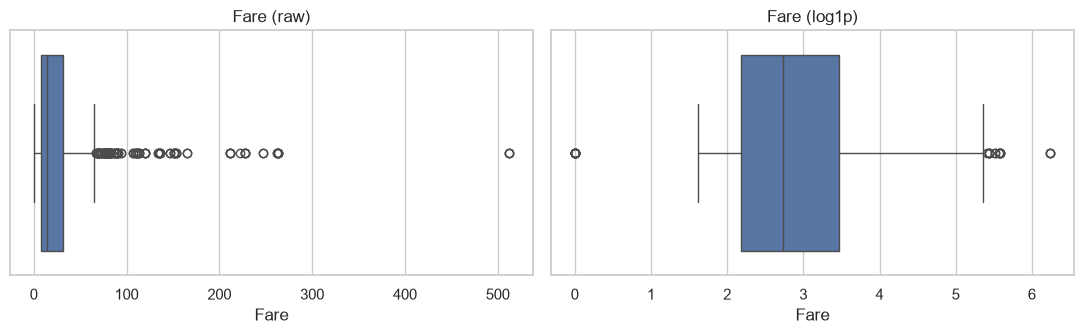

In [12]:
q1, q3 = df["Fare"].quantile([0.25, 0.75])
upper_fence = q3 + 1.5 * (q3 - q1)
outliers = df[df["Fare"] > upper_fence]

print(f"Upper IQR fence for Fare: {upper_fence:.2f}")
print("Fare outliers:", len(outliers), "| max fare:", df["Fare"].max())
print("Class of Fare outliers:")
display(outliers["Pclass"].value_counts())
print("Fare > 500 rows:")
display(df[df["Fare"] > 500][["Name", "Pclass", "Ticket", "Fare", "Survived"]])

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
sns.boxplot(x=df["Fare"], ax=ax[0]); ax[0].set_title("Fare (raw)")
sns.boxplot(x=np.log1p(df["Fare"]), ax=ax[1]); ax[1].set_title("Fare (log1p)")
plt.tight_layout(); plt.show()

**Finding 5 — `Fare` is heavily right-skewed with 116 IQR outliers (13%), and 104 of them are 1st class.**
The upper fence is about 65.6. The largest fare is 512.33, shared by three 1st-class passengers on one ticket (the ticket-level price again). These look like genuine expensive tickets, not typos, so we keep them. But a few very large numbers can dominate a scaled linear model. The engineered `FarePerPerson` feature divides the shared ticket price among the people who used it, and we will check how much that reduces the skew.

### 2.5 Sampling and representation issues

In [13]:
print(f"Rows in this dataset: {len(df)}  (about 2,224 people were aboard; this is only a subset)")

print("\nSex distribution:")
display(df["Sex"].value_counts(normalize=True).round(3))
print("Class distribution:")
display(df["Pclass"].value_counts(normalize=True).sort_index().round(3))
print("Embarked distribution:")
display(df["Embarked"].value_counts(normalize=True).round(3))

print(f"Survival rate in this sample: {df['Survived'].mean():.3f}")

Rows in this dataset: 891  (about 2,224 people were aboard; this is only a subset)

Sex distribution:


Sex
male      0.648
female    0.352
Name: proportion, dtype: float64

Class distribution:


Pclass
1    0.242
2    0.207
3    0.551
Name: proportion, dtype: float64

Embarked distribution:


Embarked
S    0.724
C    0.189
Q    0.087
Name: proportion, dtype: float64

Survival rate in this sample: 0.384


**Finding 6 — The sample is a subset of the ship, with skew in who is included.**
- The 891 rows are roughly 40% of the ~2,224 people aboard. This is the well-known Kaggle training subset, not a random sample we can verify.
- The sample is 64.8% male, 55.1% 3rd class, and 72.4% boarded at Southampton.
- The survival rate here is 38.4%; the commonly cited figure for everyone aboard is about 32%. So this sample looks slightly biased towards survivors.

**Why it matters:** anything the model learns is only guaranteed to describe *this* subset. And the whole dataset is one historical event with a specific rescue policy ("women and children first"), so it cannot tell us how survival works in general.

### 2.6 Protected and sensitive attributes
`Sex` and `Age` are protected characteristics, and `Pclass` acts as a socio-economic proxy. We check whether outcomes differ across them.

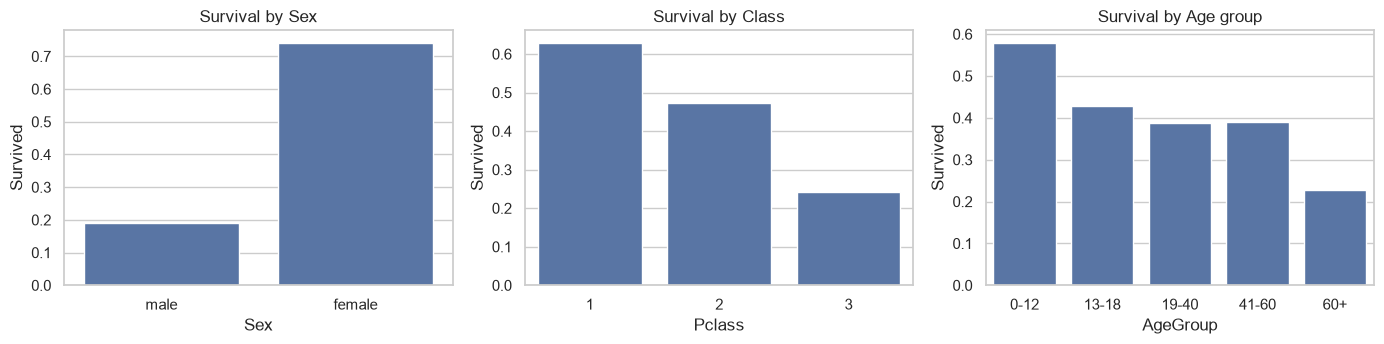

Survival by Sex x Class:


Pclass,1,2,3
Sex,,,
female,0.968,0.921,0.500
male,0.369,0.157,0.135


In [15]:
df["AgeGroup"] = pd.cut(df["Age"], [0, 12, 18, 40, 60, 100],
                        labels=["0-12", "13-18", "19-40", "41-60", "60+"])

fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
sns.barplot(data=df, x="Sex", y="Survived", ax=ax[0], errorbar=None); ax[0].set_title("Survival by Sex")
sns.barplot(data=df, x="Pclass", y="Survived", ax=ax[1], errorbar=None); ax[1].set_title("Survival by Class")
sns.barplot(data=df, x="AgeGroup", y="Survived", ax=ax[2], errorbar=None); ax[2].set_title("Survival by Age group")
plt.tight_layout(); plt.show()

print("Survival by Sex x Class:")
display(df.pivot_table(values="Survived", index="Sex", columns="Pclass", aggfunc="mean").round(3))

**Finding 7 — Survival differs enormously across protected groups.**
Women survived at 74.2% vs 18.9% for men, and 1st class at 63.0% vs 24.2% for 3rd class. The 0-12 age band survived at 58.0%, compared with about 39% for adults aged 19-60 and 22.7% for those over 60. The Sex x Class table shows the gaps compound: 96.8% of 1st-class women survived, against 13.5% of 3rd-class men.

**Why it matters:** these gaps come from the real rescue policy and from unequal access to lifeboats, so a model that uses `Sex` and `Pclass` is learning history, not a fair rule. If a model like this were used for any decision about people, it would reproduce these inequalities. We keep the attributes because our task is to understand and predict this one event, but later we check how the model performs *per group* so its errors are visible.

## 3. Leakage & Class Imbalance Checks

### 3.1 Class imbalance

Task was destroyed but it is pending!
task: <Task pending name='Task-152' coro=<_async_in_context.<locals>.run_in_context() done, defined at C:\Users\HomePC\Desktop\titanic-feature-engineering\.venv\Lib\site-packages\ipykernel\utils.py:57> wait_for=<Task pending name='Task-153' coro=<Kernel.shell_main() running at C:\Users\HomePC\Desktop\titanic-feature-engineering\.venv\Lib\site-packages\ipykernel\kernelbase.py:597> cb=[Task.task_wakeup()]> cb=[ZMQStream._run_callback.<locals>._log_error() at C:\Users\HomePC\Desktop\titanic-feature-engineering\.venv\Lib\site-packages\zmq\eventloop\zmqstream.py:564]>
C:\Users\HomePC\Desktop\titanic-feature-engineering\.venv\Lib\site-packages\matplotlib\transforms.py:193: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  ref = weakref.ref(
Task was destroyed but it is pending!
task: <Task pending name='Task-153' coro=<Kernel.shell_main() running at C:\Users\HomePC\Desktop\titanic-feature-engineering\.venv\Lib\site-packages\ipykernel\kern

Survived
0    549
1    342
Name: count, dtype: int64
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64


C:\Users\HomePC\AppData\Local\Temp\ipykernel_19624\960920923.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(["Died (0)", "Survived (1)"])


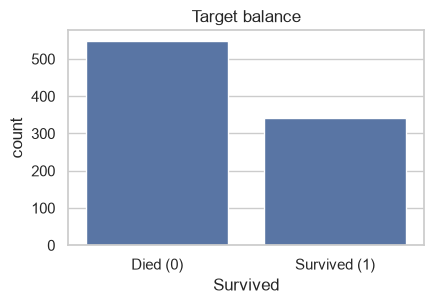

In [16]:
print(df["Survived"].value_counts())
print(df["Survived"].value_counts(normalize=True).round(3))

fig, ax = plt.subplots(figsize=(4.5, 3.2))
sns.countplot(data=df, x="Survived", ax=ax)
ax.set_xticklabels(["Died (0)", "Survived (1)"])
ax.set_title("Target balance")
plt.tight_layout()
plt.show()

**Result:** 549 passengers died (61.6%) and 342 survived (38.4%). This is a **mild** imbalance (about 1.6:1), far from extreme. A model that predicted "died" for everyone would score 61.6% accuracy while catching zero survivors, so accuracy alone is not trustworthy.

**How we handle it:**
- **Primary metric: ROC-AUC** — how well the model ranks survivors above non-survivors, independent of any threshold.
- **Supporting metrics: recall and F1 for the survived class** — how many survivors we catch, and the balance between catching them and raising false alarms.
- `class_weight="balanced"` in Logistic Regression, so the smaller class is not ignored.
- A stratified train/test split, so both sets keep the same 38/62 ratio.

### 3.2 Potential target leakage
For each column we ask: *would we know this value before the outcome, at prediction time?*

| Column | Known before the outcome? | Verdict |
|---|---|---|
| Pclass, Sex, Age, SibSp, Parch, Embarked | Yes — recorded at boarding | Safe |
| Fare, Ticket | Yes — bought before sailing | Safe |
| Name / Title | Yes | Safe |
| PassengerId | Just a row number | Dropped (no meaning; could encode file order) |
| **Cabin** | **Questionable** — see below | Only used as a "recorded or not" flag, tested carefully |

In [17]:
# Does 'HasCabin' add information beyond class? Compare survival inside each class.
tmp = df.assign(HasCabin=df["Cabin"].notna().astype(int))
print("Survival by class and HasCabin (with group sizes):")
display(tmp.groupby(["Pclass", "HasCabin"])["Survived"].agg(["mean", "size"]).round(3))

# Any numeric column suspiciously correlated with the target?
print("Correlation of numeric columns with Survived:")
display(df[["Pclass", "Age", "SibSp", "Parch", "Fare"]].corrwith(df["Survived"]).round(3).to_frame("corr_with_Survived"))

Survival by class and HasCabin (with group sizes):


mean  size
Pclass HasCabin             
1      0         0.475    40
       1         0.665   176
2      0         0.440   168
       1         0.812    16
3      0         0.236   479
       1         0.500    12

Correlation of numeric columns with Survived:


,corr_with_Survived
Pclass,-0.338
Age,-0.077
SibSp,-0.035
Parch,0.082
Fare,0.257


**Result:**
- No numeric column is suspiciously correlated with the target (all correlations are moderate, the largest being `Pclass` at about -0.34), so there is no "too good to be true" leak.
- `Cabin` is the one to watch. The cabin gap persists inside each class (e.g. 2nd class: 81.3% with a cabin vs 44.0% without, though only 16 passengers in that cell), which suggests the flag carries some information beyond class. But it might reflect *how* the data was gathered (cabin details recorded more often for survivors) rather than a real cause. We therefore treat `HasCabin` cautiously: we will test it on its own later, and we will not let it drive our conclusions.
- **Preprocessing leakage:** in the next stage, all imputers, scalers and encoders will live **inside a Pipeline** and be fitted on training folds only.
- **Feature-engineering leakage:** every engineered feature will use only feature columns, never `Survived`. One feature we'll build (`TicketGroupSize`) counts passengers across the whole file. It uses no labels, and a ship's manifest is known at boarding, so this is not target leakage, but we call it out because it's the one feature that looks across rows.

## 4. Train/Test Split & Baseline Pipeline

**Rule:** split *first*, then fit every imputer, scaler and encoder on the training data only.

- One stratified 80/20 split (`random_state=42`), created **once** and reused for both the baseline and the engineered model later. This is what makes the before/after comparison fair.
- Because a single 179-row test set is small and noisy, we also compare models with **5-fold cross-validation repeated 5 times** on the training set, using the same folds for every model.
- Baseline features are the original usable columns. `PassengerId`, `Name`, `Ticket` and `Cabin` are not used as raw inputs (IDs and free text can't go straight into a linear model, and `Cabin` is 77% empty).

In [18]:
from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, f1_score

In [19]:
target = "Survived"

# Same split for every model: we split the row INDEX once and reuse it.
train_idx, test_idx = train_test_split(
    df.index, test_size=0.2, stratify=df[target], random_state=RANDOM_STATE
)
y_train, y_test = df.loc[train_idx, target], df.loc[test_idx, target]

print("Train:", len(train_idx), "| Test:", len(test_idx))
print("Survival rate  train:", round(y_train.mean(), 3), "| test:", round(y_test.mean(), 3))

cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=RANDOM_STATE)

Train: 712 | Test: 179
Survival rate  train: 0.383 | test: 0.385


### Building the preprocessing Pipeline
- **Numeric columns:** median imputation (robust to skew and outliers) → `StandardScaler`.
- **Categorical columns:** most-frequent imputation → `OneHotEncoder(handle_unknown="ignore")` (a category unseen in training won't crash prediction on new data).
- `Pclass` is treated as **categorical**: the gap between 1st and 2nd class isn't the same as between 2nd and 3rd, so we don't force a straight line through it.
- Everything sits in a `Pipeline`, so cross-validation refits the imputer, scaler and encoder on each training fold automatically — no leakage.

In [20]:
def build_pipeline(num_cols, cat_cols):
    """Preprocessing (impute -> scale / encode) + Logistic Regression in one object."""
    numeric_steps = Pipeline([
        ("impute", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ])
    categorical_steps = Pipeline([
        ("impute", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])
    preprocess = ColumnTransformer([
        ("num", numeric_steps, num_cols),
        ("cat", categorical_steps, cat_cols),
    ])
    return Pipeline([
        ("preprocess", preprocess),
        ("model", LogisticRegression(class_weight="balanced", max_iter=1000,
                                     random_state=RANDOM_STATE)),
    ])

In [21]:
def evaluate(name, data, num_cols, cat_cols):
    """Cross-validate on train, fit on train, score on the untouched test set."""
    X = data[num_cols + cat_cols]
    pipe = build_pipeline(num_cols, cat_cols)

    cv_scores = cross_val_score(pipe, X.loc[train_idx], y_train, cv=cv, scoring="roc_auc")

    pipe.fit(X.loc[train_idx], y_train)
    proba = pipe.predict_proba(X.loc[test_idx])[:, 1]
    pred = pipe.predict(X.loc[test_idx])
    return {
        "Version": name,
        "CV AUC (mean)": cv_scores.mean(),
        "CV AUC (std)": cv_scores.std(),
        "Test AUC": roc_auc_score(y_test, proba),
        "Test Recall": recall_score(y_test, pred),
        "Test F1": f1_score(y_test, pred),
    }, cv_scores, pipe

### Baseline model — original features only

In [22]:
BASE_NUM = ["Age", "SibSp", "Parch", "Fare"]
BASE_CAT = ["Pclass", "Sex", "Embarked"]

baseline_result, baseline_cv, baseline_pipe = evaluate("Baseline", df, BASE_NUM, BASE_CAT)
pd.DataFrame([baseline_result]).round(4)

,Version,CV AUC (mean),CV AUC (std),Test AUC,Test Recall,Test F1
0,Baseline,0.8526,0.0319,0.8464,0.7826,0.7606


This is the score to beat. Notice the cross-validation standard deviation (about 0.03): small differences between models are within the noise of a dataset this size, which is why we report both CV and test results, and later check improvements fold by fold.

## 5. Feature Engineering

Each feature follows the same chain:
**existing columns → hypothesis → engineered feature → expected effect → measured result → interpretation.**
The hypotheses below are written *before* any results are looked at. Section 7 comes back to check each one.

### Feature 1 — `Title` (from `Name`)
- **Existing column:** `Name` (e.g. "Braund, **Mr.** Owen Harris").
- **What it captures:** social status, sex, marital status and a rough age band in one label: Mr, Mrs, Miss, Master (a young boy), and a Rare group for uncommon titles (Dr, Rev, Col, Countess, ...).
- **Why it might help:** `Age` is 20% missing, but a title is present for everyone, and "Master" identifies boys even when their age is unknown. Titles also separate married women (Mrs) from young unmarried women (Miss), who may have been treated differently. This is context `Sex` alone cannot capture.
- **Expected effect:** the biggest gain of all four features, mainly because it partly recovers information lost through missing ages. Moderate improvement in ROC-AUC.

### Feature 2 — `FamilyGroup` (from `SibSp` + `Parch`)
- **Existing columns:** `SibSp`, `Parch`. First build `FamilySize = SibSp + Parch + 1`, then bucket it: **Alone** (1), **Small** (2-4), **Large** (5+).
- **What it captures:** travelling context. People alone had no one to help them; small families could stay together; large families struggled to move as a group.
- **Why it might help:** the relationship between family size and survival is *not a straight line* (small groups do best, alone and large groups do worse), and a linear model cannot learn a curve from a raw count.
- **Expected effect:** small improvement. Important detail: the raw `FamilySize` on its own should add **nothing**, because `SibSp + Parch + 1` is already a linear combination of two columns the model already has. The bucketed version should add signal only because it breaks the straight line.

### Feature 3 — `HasCabin` (from `Cabin`)
- **Existing column:** `Cabin` (77% missing).
- **What it captures:** whether a cabin was recorded at all (1/0).
- **Why it might help:** a recorded cabin is a marker of upper-deck / upper-class passengers, and section 2 showed a survival gap that persists within class.
- **Expected effect:** small gain in ROC-AUC, but it's the riskiest feature. It may reflect *record-keeping* (cabins known for survivors) rather than a real cause, as flagged in section 3. Any gain here should be treated with suspicion, not celebrated.

### Feature 4 — `FarePerPerson` (from `Fare` and `Ticket`)
- **Existing columns:** `Fare`, `Ticket`. `TicketGroupSize` = number of passengers sharing the ticket; `FarePerPerson = Fare / TicketGroupSize`.
- **What it captures:** what each person actually paid, fixing the finding from section 2.2 that `Fare` is a shared, ticket-level price.
- **Why it might help:** a 7-person family on a 69.55 ticket looks wealthy per row, and it isn't. Per-person price is a cleaner wealth signal and less skewed.
- **Expected effect:** little to no gain. `Pclass` already captures most of the wealth information, so we expect this feature to overlap heavily with what the model already knows. If it doesn't help, that's a legitimate result, not a failure.

In [23]:
def add_features(d):
    """Row-wise feature engineering. Uses feature columns only -- never the target."""
    d = d.copy()

    # Feature 1: Title -- text between the comma and the first full stop in Name
    title = d["Name"].str.extract(r", ([^\.]+)\.")[0].str.strip()
    title = title.replace({"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"})
    d["Title"] = title.where(title.isin(["Mr", "Mrs", "Miss", "Master"]), "Rare")

    # Feature 2: FamilySize (intermediate) -> FamilyGroup (bucketed)
    d["FamilySize"] = d["SibSp"] + d["Parch"] + 1
    d["FamilyGroup"] = pd.cut(d["FamilySize"], bins=[0, 1, 4, 20],
                              labels=["Alone", "Small", "Large"]).astype(str)

    # Feature 3: HasCabin -- was any cabin recorded?
    d["HasCabin"] = d["Cabin"].notna().astype(int)

    # Feature 4: FarePerPerson -- ticket price split across people sharing the ticket
    d["TicketGroupSize"] = d.groupby("Ticket")["Ticket"].transform("count")
    d["FarePerPerson"] = d["Fare"] / d["TicketGroupSize"]
    return d


fe = add_features(df)
fe[["Name", "Title", "SibSp", "Parch", "FamilySize", "FamilyGroup", "Cabin", "HasCabin",
    "Fare", "TicketGroupSize", "FarePerPerson"]].head(8)

,Name,Title,SibSp,Parch,FamilySize,FamilyGroup,Cabin,HasCabin,Fare,TicketGroupSize,FarePerPerson
0,"Braund, Mr. Owen Harris",Mr,1,0,2,Small,NaN,0,7.2500,1,7.25000
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,1,0,2,Small,C85,1,71.2833,1,71.28330
2,"Heikkinen, Miss. Laina",Miss,0,0,1,Alone,NaN,0,7.9250,1,7.92500
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,1,0,2,Small,C123,1,53.1000,2,26.55000
4,"Allen, Mr. William Henry",Mr,0,0,1,Alone,NaN,0,8.0500,1,8.05000
5,"Moran, Mr. James",Mr,0,0,1,Alone,NaN,0,8.4583,1,8.45830
6,"McCarthy, Mr. Timothy J",Mr,0,0,1,Alone,E46,1,51.8625,1,51.86250
7,"Palsson, Master. Gosta Leonard",Master,3,1,5,Large,NaN,0,21.0750,4,5.26875


#### Sanity check: do the new features look sensible? (Descriptive only, no model yet)

In [24]:
print("Title counts and survival:")
display(fe.groupby("Title")["Survived"].agg(["mean", "size"]).round(3))

print("FamilyGroup counts and survival:")
display(fe.groupby("FamilyGroup")["Survived"].agg(["mean", "size"]).round(3))

print("Fare vs FarePerPerson -- skewness (lower = less skewed):")
print("  Fare:", round(fe["Fare"].skew(), 2), "| FarePerPerson:", round(fe["FarePerPerson"].skew(), 2))
print("Rows with FarePerPerson == 0 (inherited from zero fares):", (fe["FarePerPerson"] == 0).sum())

Title counts and survival:


,mean,size
Title,,
Master,0.575,40
Miss,0.703,185
Mr,0.157,517
Mrs,0.794,126
Rare,0.348,23


FamilyGroup counts and survival:


,mean,size
FamilyGroup,,
Alone,0.304,537
Large,0.161,62
Small,0.579,292


Fare vs FarePerPerson -- skewness (lower = less skewed):
  Fare: 4.79 | FarePerPerson: 4.38
Rows with FarePerPerson == 0 (inherited from zero fares): 15


The descriptive tables agree with our reasoning: survival is high for Mrs/Miss/Master and low for Mr; small families survive far more than passengers travelling alone or in large groups. Whether this translates into *model* improvement is a separate question, tested next.

## 6. Engineered Model
Same split, same folds, same metrics, same model. The only change: the four new features are added. Numeric additions (`HasCabin`, `FarePerPerson`) are imputed and scaled; categorical additions (`Title`, `FamilyGroup`) are one-hot encoded — all inside the same Pipeline.

In [25]:
ENG_NUM = BASE_NUM + ["HasCabin", "FarePerPerson"]
ENG_CAT = BASE_CAT + ["Title", "FamilyGroup"]

engineered_result, engineered_cv, engineered_pipe = evaluate("Engineered", fe, ENG_NUM, ENG_CAT)
pd.DataFrame([engineered_result]).round(4)

,Version,CV AUC (mean),CV AUC (std),Test AUC,Test Recall,Test F1
0,Engineered,0.871,0.0285,0.869,0.8261,0.7862


## 7. Before/After Comparison & Hypothesis Evaluation

### 7.1 Overall comparison (same split, same folds, same metrics)

In [26]:
comparison = pd.DataFrame([baseline_result, engineered_result]).set_index("Version")
delta = (comparison.loc["Engineered"] - comparison.loc["Baseline"]).rename("Change (Engineered - Baseline)")
display(comparison.round(4))
display(delta.round(4).to_frame())

# Paired comparison: same 25 folds, so we can ask "did the engineered model win each fold?"
paired = engineered_cv - baseline_cv
print(f"Engineered beat baseline in {(paired > 0).sum()} of {len(paired)} folds "
      f"(mean gain {paired.mean():.4f}, std {paired.std():.4f})")

,CV AUC (mean),CV AUC (std),Test AUC,Test Recall,Test F1
Version,,,,,
Baseline,0.8526,0.0319,0.8464,0.7826,0.7606
Engineered,0.8710,0.0285,0.8690,0.8261,0.7862


,Change (Engineered - Baseline)
CV AUC (mean),0.0184
CV AUC (std),-0.0034
Test AUC,0.0227
Test Recall,0.0435
Test F1,0.0256


Engineered beat baseline in 22 of 25 folds (mean gain 0.0184, std 0.0139)


### 7.2 One feature at a time (ablation) — which features earned their place?

In [27]:
def feature_test(label, add_num=(), add_cat=()):
    num = BASE_NUM + list(add_num)
    cat = BASE_CAT + list(add_cat)
    res, scores, _ = evaluate(label, fe, num, cat)
    diff = scores - baseline_cv
    return {
        "Added to baseline": label,
        "CV AUC": res["CV AUC (mean)"],
        "Gain vs baseline": diff.mean(),
        "Folds improved": f"{(diff > 0).sum()}/{len(diff)}",
        "Test AUC": res["Test AUC"],
        "Test F1": res["Test F1"],
    }

fe["FamilySize_raw"] = fe["FamilySize"]  # only used here, to test the raw count on its own

rows = [
    feature_test("Title", add_cat=["Title"]),
    feature_test("FamilySize (raw count)", add_num=["FamilySize_raw"]),
    feature_test("FamilyGroup (bucketed)", add_cat=["FamilyGroup"]),
    feature_test("HasCabin", add_num=["HasCabin"]),
    feature_test("FarePerPerson", add_num=["FarePerPerson"]),
    feature_test("ALL four (Title+FamilyGroup+HasCabin+FarePerPerson)",
                 add_num=["HasCabin", "FarePerPerson"], add_cat=["Title", "FamilyGroup"]),
]
ablation = pd.DataFrame(rows).set_index("Added to baseline")
ablation.round(4)

,CV AUC,Gain vs baseline,Folds improved,Test AUC,Test F1
Added to baseline,,,,,
Title,0.8666,0.0140,22/25,0.8775,0.7887
FamilySize (raw count),0.8526,0.0000,4/25,0.8464,0.7606
FamilyGroup (bucketed),0.8583,0.0057,19/25,0.8552,0.7413
HasCabin,0.8565,0.0040,16/25,0.8395,0.7273
FarePerPerson,0.8523,-0.0003,15/25,0.8435,0.7606
ALL four (Title+FamilyGroup+HasCabin+FarePerPerson),0.8710,0.0184,22/25,0.8690,0.7862


### 7.3 Robustness check — does grouping families by ticket change the picture?

In [28]:
from sklearn.model_selection import StratifiedKFold, GroupKFold

# Random splits can put family members on both sides. GroupKFold keeps each ticket group together.
def strat_vs_group(num, cat):
    X = fe[num + cat]
    pipe = build_pipeline(num, cat)
    s = cross_val_score(pipe, X, df[target], cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        scoring="roc_auc").mean()
    g = cross_val_score(pipe, X, df[target], cv=GroupKFold(5), groups=df["Ticket"], scoring="roc_auc").mean()
    return s, g

b_s, b_g = strat_vs_group(BASE_NUM, BASE_CAT)
e_s, e_g = strat_vs_group(ENG_NUM, ENG_CAT)
pd.DataFrame({"Random stratified CV": [b_s, e_s], "Ticket-grouped CV": [b_g, e_g]},
            index=["Baseline", "Engineered"]).round(4)

,Random stratified CV,Ticket-grouped CV
Baseline,0.8506,0.8507
Engineered,0.8752,0.8677


### 7.4 Per-group behaviour of the engineered model (test set)

In [29]:
test_view = fe.loc[test_idx].copy()
test_view["proba"] = engineered_pipe.predict_proba(fe.loc[test_idx, ENG_NUM + ENG_CAT])[:, 1]
test_view["pred"] = engineered_pipe.predict(fe.loc[test_idx, ENG_NUM + ENG_CAT])

rows = []
for col in ["Sex", "Pclass"]:
    for value, g in test_view.groupby(col):
        rows.append({
            "Group": f"{col} = {value}", "n": len(g),
            "Actual survival rate": g["Survived"].mean(),
            "Predicted survival rate": g["pred"].mean(),
            "Recall (survivors caught)": recall_score(g["Survived"], g["pred"]),
            "AUC": roc_auc_score(g["Survived"], g["proba"]),
        })
pd.DataFrame(rows).set_index("Group").round(3)

,n,Actual survival rate,Predicted survival rate,Recall (survivors caught),AUC
Group,,,,,
Sex = female,61,0.738,0.918,1.00,0.819
Sex = male,118,0.203,0.169,0.50,0.735
Pclass = 1,45,0.556,0.667,0.84,0.772
Pclass = 2,34,0.588,0.559,0.90,0.907
Pclass = 3,100,0.240,0.270,0.75,0.816


### 7.5 Interpretation — did the results support each hypothesis?

**Overall.** The engineered model beats the baseline on every headline metric: CV ROC-AUC 0.8526 → 0.8710 (+0.018), test ROC-AUC 0.8464 → 0.8690 (+0.023), test recall 0.783 → 0.826, and test F1 0.761 → 0.786. It also won in 22 of 25 cross-validation folds. But the fold-to-fold spread is about 0.03, so this is a **modest, believable improvement, not a dramatic one**, and almost all of it comes from one feature.

| Feature | Hypothesis said | Result (CV AUC gain, folds improved) | Verdict |
|---|---|---|---|
| **Title** | Biggest gain, by recovering information lost to missing ages | **+0.0140, 22/25 folds**, test AUC 0.8775 (highest of any single feature) | ✅ **Supported.** The only feature that clearly earned its place. |
| **FamilyGroup** | Small gain; the raw count alone should add nothing | Raw `FamilySize`: **+0.0000** (4/25 folds). Bucketed `FamilyGroup`: **+0.0057** (19/25 folds) | ✅ **Supported, both parts.** The raw count is exactly redundant with `SibSp + Parch`; bucketing adds a little because it captures a curve. The gain is small and test F1 dropped, so treat it as weak evidence. |
| **HasCabin** | Small gain, but risky | **+0.0040, 16/25 folds**; test AUC and F1 *fell* | ⚠️ **Partly supported.** A tiny CV gain that does not hold on the test set, and it's within noise. Combined with the leakage concern from section 3, we do not trust it. |
| **FarePerPerson** | Little or no gain, because `Pclass` already carries the wealth signal | **-0.0003, 15/25 folds** | ✅ **Supported** (the "no gain" prediction). It adds no usable signal beyond `Fare` and `Pclass`. |

**Robustness check (7.3).** With random splits the engineered model scores higher than under ticket-grouped CV, while the baseline barely moves between the two. So part of the engineered model's edge is the model recognising relatives it has already seen in training: the gain over baseline shrinks once family groups are kept together across folds. The gain is real, but smaller than the headline number suggests.

**Per-group behaviour (7.4).** The model catches nearly every surviving woman but predicts a higher share of women survive than actually did, meaning it over-predicts survival for women. For men, it catches roughly half of the actual survivors. The model is leaning heavily on `Sex`, exactly as the audit in section 2.6 warned it would.

## 8. Conclusion

### Which features added useful signal?
- **`Title`** is the one clearly useful feature (largest CV AUC gain, better in the large majority of folds). It recovers status, marital and age information for every passenger, including the ~20% with no recorded age.
- **`FamilyGroup`** added a small amount, and only because bucketing turned a non-linear relationship (small families survive most, alone and large families least) into something a linear model can use.

### Which features did not help, and what does that mean?
- **Raw `FamilySize`** added essentially nothing. It is `SibSp + Parch + 1`, which a linear model can already build from the two columns it has. A new column is not new *information* unless it does something the model could not already do — this is the key lesson from section 5's hypothesis.
- **`FarePerPerson`** added nothing measurable. `Pclass` and `Fare` already carry the wealth signal, so a "cleaner" fare is redundant.
- **`HasCabin`** gave a tiny CV gain that disappeared on the test set. It is unreliable, and we suspect it partly reflects how cabin records were collected rather than a cause of survival.

### Data-quality findings (with evidence)
1. **`Age` is missing for 177 passengers (19.9%) and not at random.** Passengers with a missing age are disproportionately 3rd class and have a lower survival rate than passengers with a known age. One global median hides this group.
2. **`Cabin` is 77.1% missing and the missingness is informative.** Having a recorded cabin is strongly tied to 1st class, and a survival gap between "has a cabin" and "no cabin" persists even within the same class. This makes `Cabin` both hard to use directly and a possible leakage-style trap.
3. **`Fare` is a ticket-level price, not a per-person price, and contains 15 zero fares.** Nearly every ticket has a single fare value shared by everyone on it (the Sage family of 7 all show the same fare), and the 15 zero-fare passengers (all boarding at Southampton) are likely crew, guests, or missing values coded as 0.
4. **Observations are not independent.** Roughly 39% of passengers share a ticket with someone else, and most multi-person tickets share a single outcome (everyone lived or everyone died). Random splits let family information leak across train and test, which is why the engineered model's cross-validation score fell under ticket-grouped folds.
5. **Sampling and protected-attribute skew.** The 891-row sample is roughly 40% of everyone aboard, skews male and 3rd class, and has a slightly higher survival rate than commonly cited for the full ship. Survival differs enormously by `Sex` and `Pclass`, reflecting the real rescue policy rather than any general rule about who "deserves" to survive.

### How these issues affect model reliability
- **Missing `Age` and `Cabin`** mean the model is partly guessing for the most vulnerable, lowest-class passengers, so its errors are likely to be worst exactly where survival was lowest.
- **Non-independent rows** make random-split scores optimistic; the honest performance is closer to the ticket-grouped numbers from section 7.3.
- **The sample skew and one-off historical event** mean the model describes *this dataset*, not survival in general. Its strong reliance on `Sex` and `Pclass` reproduces the real inequality of the rescue rather than a fair rule, and it should not be used to inform decisions about people.
- **Small data (891 rows, 179 in test)** means differences of a few thousandths in AUC are noise. Only `Title`'s gain is large and consistent enough to trust.

### Class imbalance
The roughly 62%/38% split between "died" and "survived" is mild, not severe. It was handled with a stratified split, `class_weight="balanced"` in the model, and ROC-AUC/recall/F1 as metrics instead of plain accuracy, which would have rewarded a model that just guessed "died" every time.